Before building the ridge regression model, let's first try to understand the dataset according to our problem statement

The goal is to make a ridge regression model that would calculate hike, so we have to work on the dataset to make the dataset and the model generic enough to be suitable in any sort of situation

In [120]:
import pandas as pd

In [121]:
df=pd.read_csv("HR_Analytics.csv")

In [122]:
df.columns

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab',
       'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [123]:
df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [124]:
df["PercentSalaryHike"]

,PercentSalaryHike
0,13
1,12
2,14
3,15
4,12
...,...
1475,11
1476,19
1477,14
1478,18


In [125]:
df["PercentSalaryHike"].skew()

np.float64(0.8191177544381101)

<Axes: >

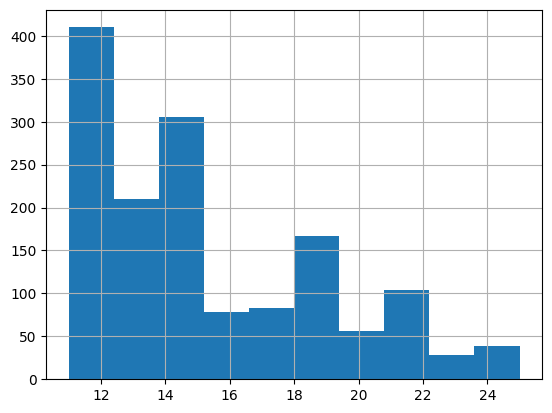

In [126]:
df["PercentSalaryHike"].hist()

It is clear that the values are skewed to the right based on both visualsation of distribution and the by using skew() function which resulted in value greater than zero, indicating right skew

The problem is if you train a model using such skewed dataset, the ridge regression woud get biased to larger values. Therefore let's bring down the values by applying log transformation

In [127]:
import numpy as np
df["PercentSalaryHike"]=np.log(df["PercentSalaryHike"])

In [128]:
df["PercentSalaryHike"].skew()

np.float64(0.4922351722986571)

<Axes: >

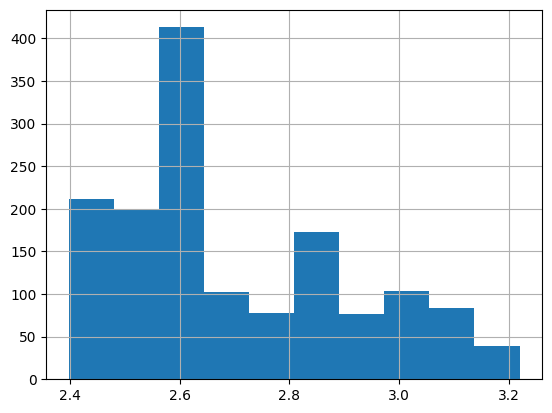

In [129]:
df["PercentSalaryHike"].hist()

We have reduced the skew from 0.8 to 0.4 which is moderately acceptable, applying log transformation again would compress the values too much, so let's stop with this and continue

Now let's start dropping some columns that are unnecessary and would cause unwanted behaviour of the model

In [130]:
df.drop(["EmpID","EmployeeNumber"],axis=1,inplace=True) #columns that provides no purpose for our model

In [131]:
df[['EmployeeCount', 'StandardHours', 'Over18']].nunique() #all values in the column is the same

,0
EmployeeCount,1
StandardHours,1
Over18,1


In [132]:
df.drop(['EmployeeCount', 'StandardHours', 'Over18'],axis=1,inplace=True)

In [133]:
df.drop(['AgeGroup'],axis=1,inplace=True) #since we have the exact age , we wouldn't need this

In [134]:
df.drop(['SalarySlab'],axis=1,inplace=True) # we have the exact salary we don't need the range

In [135]:
df.drop(['MonthlyIncome', 'DailyRate', 'HourlyRate', 'MonthlyRate'], axis=1, inplace=True)

In [136]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [137]:
df.shape

(1480, 27)

We have to make the model generic, so we have to consider the education field column and how it affects the result, let's find it by calculating the mean

In [138]:
df.groupby("EducationField")["PercentSalaryHike"].mean() #we are grouping based on each education field and finding mean of salaryhike for each group

,PercentSalaryHike
EducationField,
Human Resources,2.668008
Life Sciences,2.697617
Marketing,2.675701
Medical,2.705801
Other,2.714000
Technical Degree,2.663017


Since there is no very significant difference, it would be little safe to drop the column helping the model to be more generic

In [139]:
df.drop(["EducationField"],axis=1,inplace=True)

In [140]:
for col in ['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus']:
    print(f"\n{col}:")
    print(df.groupby(col)['PercentSalaryHike'].mean().sort_values(ascending=False))


BusinessTravel:
BusinessTravel
Non-Travel           2.724192
Travel_Rarely        2.694275
Travel_Frequently    2.690464
TravelRarely         2.419648
Name: PercentSalaryHike, dtype: float64

Department:
Department
Research & Development    2.700524
Sales                     2.687831
Human Resources           2.664342
Name: PercentSalaryHike, dtype: float64

JobRole:
JobRole
Sales Representative         2.728143
Manufacturing Director       2.722681
Healthcare Representative    2.711335
Research Scientist           2.710393
Manager                      2.684732
Laboratory Technician        2.684529
Research Director            2.679343
Sales Executive              2.674068
Human Resources              2.667778
Name: PercentSalaryHike, dtype: float64

MaritalStatus:
MaritalStatus
Married     2.699762
Single      2.695775
Divorced    2.684588
Name: PercentSalaryHike, dtype: float64


In [141]:
df['BusinessTravel'] = df['BusinessTravel'].str.replace('TravelRarely', 'Travel_Rarely')

In [142]:
df.drop(['BusinessTravel', 'Department', 'JobRole', 'MaritalStatus'],axis=1,inplace=True)

In [143]:
df.columns.tolist()

['Age',
 'Attrition',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'Gender',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [144]:
df.shape

(1480, 22)

Now as we have dropped all the unecessary columns, let's find the columns that are not numeric before training the model

In [145]:
print(df.select_dtypes(include='object').columns.tolist())

['Attrition', 'Gender', 'OverTime']


Obivously attrition is not necessary, since we are not going to give hike to a person if they are going to left

In [146]:
df.drop(["Attrition"],axis=1,inplace=True)

Now let's do label encoding on the columns that are not in float or integer format

In [147]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])
df["Gender"]

,Gender
0,1
1,0
2,1
3,1
4,1
...,...
1475,0
1476,0
1477,1
1478,1


In [148]:
df["OverTime"]=le.fit_transform(df["OverTime"])

Let's verify if there exists any string columns

In [149]:
df.select_dtypes(include='object').columns.tolist()

[]

Empty list indicates that there are no columns that are having any sort of string values

In [150]:
df.shape

(1480, 21)

In [151]:
df.dtypes #let's check the type of values each column has

,0
Age,int64
DistanceFromHome,int64
Education,int64
EnvironmentSatisfaction,int64
Gender,int64
JobInvolvement,int64
JobLevel,int64
JobSatisfaction,int64
NumCompaniesWorked,int64
OverTime,int64


Now it is time to split the datasets

In [152]:
from sklearn.model_selection import train_test_split
y=df["PercentSalaryHike"]
X=df.drop(["PercentSalaryHike"],axis=1)
print(y.shape)
print(X.shape)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

(1480,)
(1480, 20)


Let's do scaling of the dataset so that the model doesn't get influenced by larger values

In [153]:
# Confirm missing values
print(df['YearsWithCurrManager'].isnull().sum())  # will show 50

# Check if any other column has missing values too
print(df.isnull().sum())

57
Age                          0
DistanceFromHome             0
Education                    0
EnvironmentSatisfaction      0
Gender                       0
JobInvolvement               0
JobLevel                     0
JobSatisfaction              0
NumCompaniesWorked           0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StockOptionLevel             0
TotalWorkingYears            0
TrainingTimesLastYear        0
WorkLifeBalance              0
YearsAtCompany               0
YearsInCurrentRole           0
YearsSinceLastPromotion      0
YearsWithCurrManager        57
dtype: int64


In [154]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Fit only on train, transform both
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

In [155]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_imputed)
X_test_scaled=scaler.transform(X_test_imputed)

In [156]:
import pandas as pd

# Mean should be ~0 and std should be ~1 for all columns
scaled_check = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print(scaled_check.describe().round(2))

           Age  DistanceFromHome  Education  EnvironmentSatisfaction   Gender  \
count  1184.00           1184.00    1184.00                  1184.00  1184.00   
mean     -0.00              0.00       0.00                     0.00    -0.00   
std       1.00              1.00       1.00                     1.00     1.00   
min      -2.06             -1.02      -1.86                    -1.60    -1.23   
25%      -0.74             -0.90      -0.89                    -0.69    -1.23   
50%      -0.20             -0.28       0.08                     0.23     0.81   
75%       0.68              0.59       1.05                     1.15     0.81   
max       2.54              2.45       2.02                     1.15     0.81   

       JobInvolvement  JobLevel  JobSatisfaction  NumCompaniesWorked  \
count         1184.00   1184.00          1184.00             1184.00   
mean            -0.00     -0.00            -0.00                0.00   
std              1.00      1.00             1.00      

Let's start training the model

In [159]:
from sklearn.linear_model import RidgeCV
import numpy as np
alphas =[0.001,0.01,0.1,1,10,50,100,200]
ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5, # 5fold cross validations
    scoring='neg_mean_squared_error'
)
ridge_cv.fit(X_train_scaled,y_train)

RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 50, 100, 200], cv=5,
        scoring='neg_mean_squared_error')

In [162]:
ridge_cv.alpha_ #the best alpha that was chosen by the model

np.float64(10.0)

Okay let's get the predictions and analyze the performance of the model

In [163]:
y_pred_log=ridge_cv.predict(X_test_scaled)
y_pred_actual=np.exp(y_pred_log)
y_test_actual=np.exp(y_test)

In [164]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2   = r2_score(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae  = mean_absolute_error(y_test_actual, y_pred_actual)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}"
)
print(f"MAE      : {mae:.4f}")

R² Score : 0.5341
RMSE     : 2.3358
MAE      : 1.8966


The results are not optimal but moderately good

In [165]:
# Finding if the model is perfect/overfitting/underfitting
y_train_pred = ridge_cv.predict(X_train_scaled)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_pred_log)

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")

Train R²: 0.5209
Test  R²: 0.5341


In [166]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': ridge_cv.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.head(10))

                     Feature  Coefficient
10         PerformanceRating     0.160815
16            YearsAtCompany    -0.009071
0                        Age     0.008686
1           DistanceFromHome     0.006121
19      YearsWithCurrManager    -0.005735
6                   JobLevel    -0.005514
18   YearsSinceLastPromotion    -0.004889
17        YearsInCurrentRole     0.004291
11  RelationshipSatisfaction    -0.003648
3    EnvironmentSatisfaction    -0.003088


The model is okay but it is highly influenced by the performance score so the performance score should be calculated in the right manner before the predicting the hike percentage using this model

Let's try some custom input and the result

In [167]:
import numpy as np
import pandas as pd

# Sample input — one employee's details
# Fill in values based on your actual data ranges
sample_employee = {
    'Age'                      : 35,
    'DistanceFromHome'         : 10,
    'Education'                : 3,       # 1=Below College, 2=College, 3=Bachelor, 4=Master, 5=Doctor
    'EnvironmentSatisfaction'  : 3,       # 1=Low, 2=Medium, 3=High, 4=Very High
    'Gender'                   : 1,       # 0=Female, 1=Male
    'JobInvolvement'           : 3,       # 1=Low, 2=Medium, 3=High, 4=Very High
    'JobLevel'                 : 2,       # 1 to 5
    'JobSatisfaction'          : 3,       # 1=Low, 2=Medium, 3=High, 4=Very High
    'NumCompaniesWorked'       : 3,
    'OverTime'                 : 0,       # 0=No, 1=Yes
    'PerformanceRating'        : 3,       # 3=Excellent, 4=Outstanding
    'RelationshipSatisfaction' : 3,       # 1=Low, 2=Medium, 3=High, 4=Very High
    'StockOptionLevel'         : 1,       # 0 to 3
    'TotalWorkingYears'        : 10,
    'TrainingTimesLastYear'    : 3,
    'WorkLifeBalance'          : 3,       # 1=Bad, 2=Good, 3=Better, 4=Best
    'YearsAtCompany'           : 5,
    'YearsInCurrentRole'       : 3,
    'YearsSinceLastPromotion'  : 1,
    'YearsWithCurrManager'     : 3
}

# Convert to dataframe
sample_df = pd.DataFrame([sample_employee])

# Step 1 — Impute (handles YearsWithCurrManager if missing)
sample_imputed = imputer.transform(sample_df)

# Step 2 — Scale using the same scaler fitted on training data
sample_scaled = scaler.transform(sample_imputed)

# Step 3 — Predict (model returns log transformed value)
predicted_log = ridge_cv.predict(sample_scaled)

# Step 4 — Reverse log transformation to get actual hike %
predicted_hike = np.exp(predicted_log)[0]

print("=" * 40)
print("       SALARY HIKE PREDICTION")
print("=" * 40)
print(f"  Performance Rating  : {sample_employee['PerformanceRating']}")
print(f"  Job Level           : {sample_employee['JobLevel']}")
print(f"  Years at Company    : {sample_employee['YearsAtCompany']}")
print(f"  OverTime            : {'Yes' if sample_employee['OverTime'] == 1 else 'No'}")
print("-" * 40)
print(f"  Predicted Hike      : {predicted_hike:.2f}%")
print("=" * 40)

       SALARY HIKE PREDICTION
  Performance Rating  : 3
  Job Level           : 2
  Years at Company    : 5
  OverTime            : No
----------------------------------------
  Predicted Hike      : 13.94%
